## Step 4: Pre-Processing — Tri-Stereo Bundle Adjustment, Initial DEM, and Map Projection

This step performs the core **geometric pre-processing** required to prepare the tri-stereo images for accurate DSM generation. It consists of the following sub-steps:

### 1. Bundle Adjustment (BA)
A first bundle adjustment is performed on the raw, unprojected tri-stereo images (`A.tif`, `B.tif`, `C.tif`) using rational polynomial coefficients (RPCs). This aligns the image orientations to improve epipolar geometry consistency.

In [19]:
%%bash
source Metadata-Copy1.sh

# ============================================================
# 1. BUNDLE ADJUSTMENT
# ============================================================
bundle_adjust \
    -t rpc \
    "${IMAGE_FILES[@]}" \
    "${RPC_FILES[@]}" \
    --cost-function Cauchy \
    --robust-threshold 2.0 \
    --max-iterations 500 \
    --datum WGS84 \
    --threads 0 \
    --tif-compress Deflate \
    -o "${BA_PREFIX}" \
    2>&1 | tee "${BA_LOG}"

	--> Setting number of processing threads to: 4
Found 0 GCP files on the command line.
Will use the datum:
Geodetic Datum --> Name: WGS_1984  Spheroid: WGS 84  Semi-major axis: 6378137  Semi-minor axis: 6356752.3142451793  Meridian: Greenwich at 0  Proj4 Str: +proj=longlat +datum=WGS84 +no_defs

Creating output directory: "/mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/ba_ABC".
Writing log info to: /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/ba_ABC/ABC-log-bundle_adjust-07-13-1723-25937.txt
Using session: rpc
Loading camera model: /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.tif /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.XML
Using session: rpc
Loading camera model: /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/B_crop.tif /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/B_crop.XML
Using session: rpc
Loading camera model: /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cr

In [20]:
# ============================================================
# DISPLAY BUNDLE-ADJUSTMENT RESIDUALS
# ============================================================

from importlib import reload
import asp_workflow_utils as asp_utils

# Reload after modifying asp_workflow_utils.py
reload(asp_utils)

residual_summary = asp_utils.get_bundle_adjustment_residuals(
    "Metadata-Copy1.sh"
)

display(residual_summary)

,Initial mean (px),Final mean (px),Initial median (px),Final median (px),Point count
Image,,,,,
A,0.2027,0.1242,0.1615,0.1063,3427
B,0.1088,0.1222,0.0743,0.1061,3377
C,0.1424,0.1418,0.1248,0.1230,3461


### 2. Initial Stereo Correlation
Stereo matching is performed on the unprojected images using the ASP Block Matching algorithm (`asp_bm`). This generates a low-precision point cloud (`*-PC.tif`) without requiring map projection.

In [22]:
%%bash

source Metadata-Copy1.sh

# ============================================================
# 2. INITIAL STEREO CORRELATION
# ============================================================

# Fixed processing parameters for the preliminary DSM
PRELIM_STEREO_ALGORITHM="asp_bm"
PRELIM_XCORR_THRESHOLD=2
PRELIM_COST_MODE=2
PRELIM_CORR_KERNEL=(35 35)
PRELIM_SUBPIXEL_KERNEL=(45 45)
PRELIM_SUBPIXEL_MODE=2


# ------------------------------------------------------------
# Automatically identify the required adjustment files
# ------------------------------------------------------------
PRELIM_LEFT_STEM="$(basename "${PRELIM_LEFT_IMAGE}" .tif)"
PRELIM_RIGHT_STEM="$(basename "${PRELIM_RIGHT_IMAGE}" .tif)"

PRELIM_LEFT_ADJUST="${BA_PREFIX}-${PRELIM_LEFT_STEM}.adjust"
PRELIM_RIGHT_ADJUST="${BA_PREFIX}-${PRELIM_RIGHT_STEM}.adjust"

# ------------------------------------------------------------
# Display only the important information
# ------------------------------------------------------------

echo ""
echo "============================================================"
echo "INITIAL STEREO CORRELATION"
echo "============================================================"
echo "Pair          : ${PRELIM_PAIR_TAG}"
echo "Left image    : ${PRELIM_LEFT_IMAGE}"
echo "Right image   : ${PRELIM_RIGHT_IMAGE}"
echo "Output prefix : ${PRELIM_PREFIX}"
echo "============================================================"
echo ""


# ------------------------------------------------------------
# Run preliminary stereo reconstruction
# ------------------------------------------------------------
parallel_stereo \
    -t "${CAMERA_SESSION}" \
    --stereo-algorithm "${PRELIM_STEREO_ALGORITHM}" \
    --xcorr-threshold "${PRELIM_XCORR_THRESHOLD}" \
    --cost-mode "${PRELIM_COST_MODE}" \
    --corr-kernel "${PRELIM_CORR_KERNEL[@]}" \
    --subpixel-kernel "${PRELIM_SUBPIXEL_KERNEL[@]}" \
    --corr-tile-size "${corr_tile_size}" \
    --corr-memory-limit-mb "${corr_mem_limit_mb}" \
    --subpixel-mode "${PRELIM_SUBPIXEL_MODE}" \
    --bundle-adjust-prefix "${BA_PREFIX}" \
    "${PRELIM_LEFT_IMAGE}" \
    "${PRELIM_RIGHT_IMAGE}" \
    "${PRELIM_LEFT_RPC}" \
    "${PRELIM_RIGHT_RPC}" \
    "${PRELIM_PREFIX}" \
    2>&1 | tee "${PRELIM_LOG}"


INITIAL STEREO CORRELATION
Pair          : AC
Left image    : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.tif
Right image   : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/C_crop.tif
Output prefix : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/dems/stereo_preliminary_AC/preliminary

sed: /mnt/summer/USERS/KOAI/ASP/StereoPipeline-3.3.0-Linux/lib/libselinux.so.1: no version information available (required by sed)
sed: /mnt/summer/USERS/KOAI/ASP/StereoPipeline-3.3.0-Linux/lib/libselinux.so.1: no version information available (required by sed)
find: /mnt/summer/USERS/KOAI/ASP/StereoPipeline-3.3.0-Linux/lib/libselinux.so.1: no version information available (required by find)

[ 2026-Jul-13 17:26:01 ] : Stage 0 --> PREPROCESSING 
	--> Setting number of processing threads to: 64
Stereo file ./stereo.default could not be found. Will use default settings and command line options only.
Writing log info to: /mnt/summer/USERS/KOAI/Berare

#### 3. Low-Quality DEM Generation
The preliminary point cloud is converted into a coarse DEM using `point2dem`. This acts as a first approximation of surface elevation and is used for alignment.

In [30]:
%%bash

source Metadata-Copy1.sh
set -euo pipefail

# ============================================================
# GENERATE PRELIMINARY ALIGNMENT DEM
# ============================================================

# Processing parameters
PRELIM_DEM_RESOLUTION=1
PRELIM_DEM_NODATA=-9999


# Check the automatically linked point cloud
require_files "${PRELIM_POINT_CLOUD}"


# Remove old DEM outputs when overwrite is enabled
prepare_output_prefix \
    "${PRELIM_DEM_PREFIX}" \
    "${PRELIM_DEM_LOG}"


echo ""
echo "============================================================"
echo "GENERATE PRELIMINARY ALIGNMENT DEM"
echo "============================================================"
echo "Input point cloud : ${PRELIM_POINT_CLOUD}"
echo "Target CRS        : ${proj}"
echo "Resolution        : ${PRELIM_DEM_RESOLUTION} m"
echo "Output DEM        : ${PRELIM_DEM}"
echo "============================================================"
echo ""


point2dem \
    --t_srs "${proj}" \
    --tr "${PRELIM_DEM_RESOLUTION}" \
    --threads 0 \
    --nodata-value "${PRELIM_DEM_NODATA}" \
    "${PRELIM_POINT_CLOUD}" \
    -o "${PRELIM_DEM_PREFIX}" \
    2>&1 | tee "${PRELIM_DEM_LOG}"


# Confirm that point2dem created the DEM
require_files "${PRELIM_DEM}"


echo ""
echo "Preliminary alignment DEM completed:"
echo "  ${PRELIM_DEM}"


GENERATE PRELIMINARY ALIGNMENT DEM
Input point cloud : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/dems/stereo_preliminary_AC/preliminary-PC.tif
Target CRS        : EPSG:32632
Resolution        : 1 m
Output DEM        : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/dems/preliminary_AC-DEM.tif

	--> Setting number of processing threads to: 4
Writing log info to: /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/dems/preliminary_AC-log-point2dem-07-13-1819-36453.txt
Statistics: [********************************************************] Complete!
Bounding box and triangulation error range estimation: [*************] Complete!
QuadTree: [**********************************************************] Complete!
Collected a sample of 8595914 positive triangulation errors.
Error percentiles: Q1 (25%): 0.0105286, Q2 (50%): 0.0231628, Q3 (75%): 0.0447464.
Computing triangulation error cutoff based on --remove-outliers-params.
Triangulation error cutoff is 0.134239

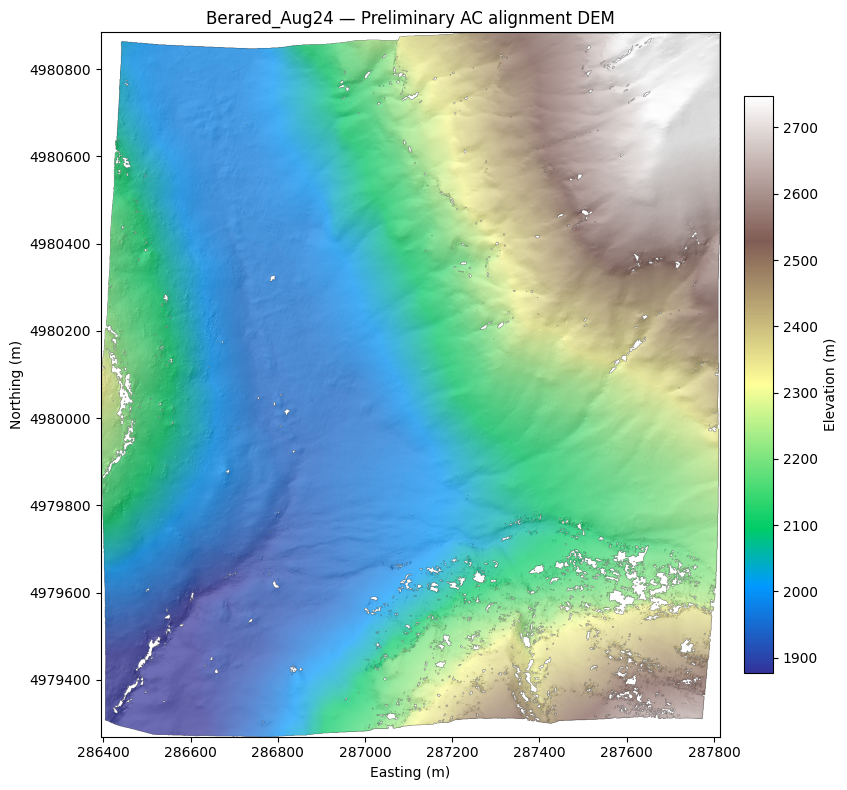

PosixPath('/mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/dems/preliminary_AC-DEM.tif')

In [6]:
# ============================================================
# DISPLAY PRELIMINARY ALIGNMENT DEM
# ============================================================

from importlib import reload
import asp_workflow_utils as asp_utils

reload(asp_utils)

asp_utils.plot_preliminary_dem(
    "Metadata-Copy1.sh"
)

### 4. Alignment with Reference DEM
The preliminary DEM is aligned to the high-accuracy reference DEM (LiDAR) using `pc_align`. This step estimates a rigid transform between the preliminary DSM and the LiDAR surface.

### 5. Second Bundle Adjustment (Transform-Aware)
The alignment transform is then applied to a second bundle adjustment to ensure that the camera models are now geometrically aligned with the reference DEM.

In [32]:
%%bash
source Metadata-Copy1.sh

# ============================================================
# ALIGN PRELIMINARY DEM TO THE 1 m LiDAR DSM
# ============================================================
# Processing parameters remain visible in the notebook
PC_ALIGN_MAX_DISPLACEMENT=250
PC_ALIGN_ITERATIONS=100

# ------------------------------------------------------------
# Check automatically linked inputs
# ------------------------------------------------------------
require_files \
    "${ALIGNMENT_DEM}" \
    "${PRELIM_DEM}"
# ------------------------------------------------------------
# Prepare alignment outputs
# ------------------------------------------------------------
prepare_output_prefix \
    "${ALIGN_PREFIX}" \
    "${ALIGN_LOG}"

echo ""
echo "============================================================"
echo "PRELIMINARY DEM ALIGNMENT"
echo "============================================================"
echo "Reference LiDAR DSM : ${ALIGNMENT_DEM}"
echo "Preliminary DSM     : ${PRELIM_DEM}"
echo "Output transform    : ${ALIGN_TRANSFORM}"
echo "============================================================"
echo ""

# ------------------------------------------------------------
# Run pc_align
#
# First input  = fixed LiDAR reference
# Second input = movable preliminary DSM
# ------------------------------------------------------------

pc_align \
    --max-displacement "${PC_ALIGN_MAX_DISPLACEMENT}" \
    --num-iterations "${PC_ALIGN_ITERATIONS}" \
    "${ALIGNMENT_DEM}" \
    "${PRELIM_DEM}" \
    -o "${ALIGN_PREFIX}" \
    2>&1 | tee "${ALIGN_LOG}"


# Confirm that the alignment transform was created
require_files "${ALIGN_TRANSFORM}"

# ============================================================
# APPLY ALIGNMENT TRANSFORM TO ALL CAMERA MODELS
# ============================================================
prepare_output_prefix \
    "${ALIGNED_BA_PREFIX}" \
    "${ALIGNED_BA_LOG}"


echo "============================================================"
echo "APPLY ALIGNMENT TRANSFORM TO CAMERAS"
echo "============================================================"

bundle_adjust \
    -t "${CAMERA_SESSION}" \
    "${IMAGE_FILES[@]}" \
    "${RPC_FILES[@]}" \
    --initial-transform "${ALIGN_TRANSFORM}" \
    --input-adjustments-prefix "${BA_PREFIX}" \
    --apply-initial-transform-only \
    --datum WGS84 \
    --threads 18 \
    --tif-compress Deflate \
    -o "${ALIGNED_BA_PREFIX}" \
    2>&1 | tee "${ALIGNED_BA_LOG}"


PRELIMINARY DEM ALIGNMENT
Reference LiDAR DSM : /mnt/summer/USERS/KOAI/Berared_Aug24/LiDAR_DEMs/Ellps/Berared_LiDAR_DSM1m_WGS84_31N.tif
Preliminary DSM     : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/dems/preliminary_AC-DEM.tif
Output transform    : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/dems/align/preliminary_AC_to_LiDAR-transform.txt

	--> Setting number of processing threads to: 4
Writing log info to: /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/dems/align/preliminary_AC_to_LiDAR-log-pc_align-07-13-1819-36655.txt
Detected datum from /mnt/summer/USERS/KOAI/Berared_Aug24/LiDAR_DEMs/Ellps/Berared_LiDAR_DSM1m_WGS84_31N.tif:
Geodetic Datum --> Name: WGS_1984  Spheroid: WGS 84  Semi-major axis: 6378137  Semi-minor axis: 6356752.3142451793  Meridian: Greenwich at 0  Proj4 Str: +datum=WGS84
Will use datum (for CSV files): Geodetic Datum --> Name: WGS_1984  Spheroid: WGS 84  Semi-major axis: 6378137  Semi-minor axis: 6356752.3142451793  Meridi


#### 6. Map Projection of Each Image
Each of the tri-stereo images is map-projected using the adjusted models onto the reference DEM grid at the desired ground sampling resolution (e.g., 0.5 m).

#### 7. Adjustment File Renaming
The `.adjust` files from the final BA step are renamed to match the naming of the newly map-projected images, ensuring consistency for subsequent processing.

In [33]:
%%bash
source Metadata-Copy1.sh

# ============================================================
# MAP PROJECT ALL ACTIVE IMAGES
# ============================================================

MAPPROJECT_THREADS=18

# ------------------------------------------------------------
# Mapproject every active image
# ------------------------------------------------------------

for index in "${!VIEW_IDS[@]}"; do

    view="${VIEW_IDS[$index]}"
    input_image="${IMAGE_FILES[$index]}"
    input_rpc="${RPC_FILES[$index]}"
    output_image="${MAPPROJECTED_IMAGES[$index]}"
    log_file="${MAPPROJECT_LOGS[$index]}"


    # Remove the previous output when overwrite is enabled
    prepare_output_prefix \
        "${output_image}" \
        "${log_file}"


    echo ""
    echo "------------------------------------------------------------"
    echo "Mapprojecting image ${view}"
    echo "Input image : ${input_image}"
    echo "Input RPC   : ${input_rpc}"
    echo "Output      : ${output_image}"
    echo "------------------------------------------------------------"


    mapproject \
        -t "${CAMERA_SESSION}" \
        --threads "${MAPPROJECT_THREADS}" \
        --tr "${rawRes_meters}" \
        --t_srs "${proj}" \
        --bundle-adjust-prefix "${ALIGNED_BA_PREFIX}" \
        --tif-compress Deflate \
        "${MAPPROJECT_DEM}" \
        "${input_image}" \
        "${input_rpc}" \
        "${output_image}" \
        2>&1 | tee "${log_file}"


    # Confirm that the map-projected image was created
    require_files "${output_image}"

done


------------------------------------------------------------
Mapprojecting image A
Input image : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.tif
Input RPC   : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.XML
Output      : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/mapproject/A_Berared_Aug24_0.5m_baL50.tif
------------------------------------------------------------
mapproject_single --t_pixelwin 0 0 3002 3412 /mnt/summer/USERS/KOAI/Berared_Aug24/LiDAR_DEMs/Ellps/Berared_LiDAR_DSM50m_WGS84_31N.tif /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.tif /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.XML /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/mapproject/A_Berared_Aug24_0_5m_baL50_tif_tiles/tile_0_0_3002_3412.tif -t rpc --threads 18 --tr 0.5 --t_srs EPSG:32632 --bundle-adjust-prefix /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/ba_aligned_ABC/AB

> ✅ This pre-processing chain ensures that stereo correlation in the next step is performed between map-projected images that are **co-registered** to both each other and the reference terrain model.

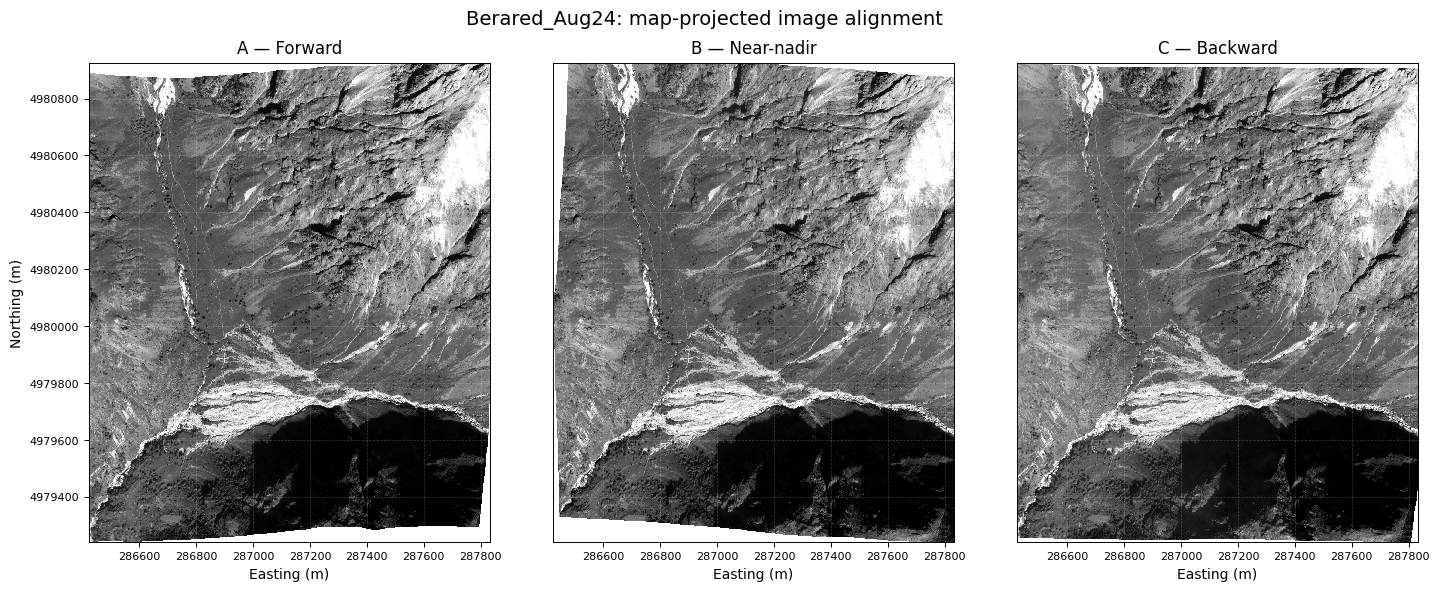

In [5]:
from importlib import reload
import asp_workflow_utils as asp_utils

reload(asp_utils)

asp_utils.plot_mapprojected_images(
    "Metadata-Copy1.sh",

    output_folder_name="Figure",

    show_grid=True,
    grid_color="white",
    grid_alpha=0.22,
    grid_linewidth=0.5,
    grid_linestyle="--",
    grid_spacing=None,

    return_images=False,
)